# Kenya Food Price Intelligence & Forecasting
## Exploratory Data Analysis & Feature Engineering

**Capstone Project — Data Science & AI Bootcamp**

---

### Background

Food prices in Kenya are volatile, regionally fragmented, and increasingly unpredictable. In 2026 alone,
maize prices swung from over **KES 4,000** per 90kg bag to below **KES 2,200** following a record harvest,
then reversed sharply back to **KES 4,500–4,600** within months as poor rains and fertilizer shortages cut
into supply. National inflation reached **6.5%** in July 2026 (KNBS), with food and non-alcoholic beverages
contributing the single largest share of the increase. An estimated **3.3 million people** across Kenya's
ASAL counties are in IPC Acute Food Insecurity Phase 3 or above.

Despite the scale of this problem, most consumers, farmers, and traders rely on lagging, anecdotal price
information rather than any forward-looking signal. This project builds a **food price intelligence and
forecasting system** that turns fragmented historical market data into forward-looking, actionable insight.

### What this notebook does

This notebook performs a **complete exploratory data analysis (EDA)** and **feature engineering** pass on
the cleaned WFP + rainfall dataset, in preparation for the modeling stages of the capstone (time-series
forecasting, regression, and market clustering). Specifically, we will:

1. **Inspect** the raw dataset structure, types, and quality (missing values, duplicates, coverage gaps)
2. **Clean** and standardize the data for analysis
3. **Explore** price distributions, regional coverage, commodity mix, and temporal trends
4. **Investigate** seasonality and the relationship between rainfall and prices
5. **Compare** wholesale vs. retail pricing behavior
6. **Engineer features** for later modeling: time features, lag/rolling statistics, volatility/anomaly
   flags (the "early-warning" signal from the problem statement), and rainfall-interaction features
7. **Summarize** key findings and export a modeling-ready feature dataset

Every code cell below includes a line-by-line comment explaining what it does and why, and every analytical
step is followed by a short markdown note recording what we observed in the output — this is meant to read
as a fully-documented analytical narrative, not just a chain of plots.


## 1. Setup: Imports & Configuration

In [1]:
# Importing the necessary libraries for data analysis and visualization
# Core data-handling libraries
import pandas as pd                      # DataFrame operations: loading, cleaning, grouping, reshaping
import numpy as np                       # Numerical operations: arrays, NaN handling, math functions

# Visualization libraries (per project preference: matplotlib + seaborn) 
import matplotlib.pyplot as plt          # Base plotting engine used by seaborn under the hood
import matplotlib.ticker as mticker      # Custom tick formatting (e.g. comma-separated KES values)
import seaborn as sns                    # Statistical plotting built on matplotlib; nicer defaults

# Statistics helpers used later for outlier/anomaly detection 
from scipy import stats                  # Z-scores and other statistical utilities

import warnings
warnings.filterwarnings("ignore")        # Suppress noisy library warnings so output stays readable

# Global plotting style 
sns.set_theme(style="whitegrid", palette="deep")   # Consistent, clean chart style across the notebook
plt.rcParams["figure.figsize"] = (11, 5)            # Sensible default figure size for readability
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)          # Show all columns when previewing DataFrames
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")  # Readable number formatting (no sci-notation)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the Dataset

We load the cleaned WFP (World Food Programme) Kenya food price dataset, which has already been merged
with monthly rainfall data (`rainfall_mm`) per market location.


In [2]:
# Read the CSV into a DataFrame. This file has already been cleaned/merged upstream (WFP prices + rainfall).
data = pd.read_csv("../../data/cleaned/wfp_with_rainfall.csv")

# Quick shape check: (rows, columns) — tells us how much data we're working with at a glance.
print(f"Dataset shape: {data.shape[0]:,} rows x {data.shape[1]} columns")

# Preview the first 5 rows to visually confirm the data loaded as expected and see real example values.
data.head()


Dataset shape: 27,316 rows x 18 columns


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22,2006-01-01,17.81
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,"1,480.00",20.58,2006-01-01,17.81
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47,2006-01-01,17.81
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,"3,246.00",45.15,2006-01-01,17.81
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24,2006-01-01,44.53


**Observation:** The dataset contains ~27,300 rows and 18 columns, covering commodity-level price records
per market and date, with geographic identifiers (`admin1`/`admin2`/`market`/`latitude`/`longitude`),
commodity metadata (`category`, `commodity`, `unit`), price fields (`price`, `usdprice`), and the merged
`rainfall_mm` feature. Each row represents one commodity's price at one market on one date.


## 3. Structure, Data Types & Data Quality

In [3]:
# .info() gives us column dtypes and non-null counts in one view — our first data-quality checkpoint.
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          27316 non-null  str    
 1   admin1        27316 non-null  str    
 2   admin2        27316 non-null  str    
 3   market        27316 non-null  str    
 4   market_id     27316 non-null  int64  
 5   latitude      27316 non-null  float64
 6   longitude     27316 non-null  float64
 7   category      27316 non-null  str    
 8   commodity     27316 non-null  str    
 9   commodity_id  27316 non-null  int64  
 10  unit          27316 non-null  str    
 11  priceflag     27316 non-null  str    
 12  pricetype     27316 non-null  str    
 13  currency      27316 non-null  str    
 14  price         27316 non-null  float64
 15  usdprice      27316 non-null  float64
 16  date_month    27316 non-null  str    
 17  rainfall_mm   25829 non-null  float64
dtypes: float64(5), int64(2), str(11)
memo

In [4]:
# Count missing values per column, sorted from most to least missing.
missing = data.isnull().sum().sort_values(ascending=False)

# Convert to a percentage of total rows too, since raw counts alone can be misleading on large datasets.
missing_pct = (missing / len(data) * 100).round(2)
#print(missing_pct)

# Combine both views into a single summary table for easy reading.
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

# Only display columns that actually have missing values.
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
rainfall_mm,1487,5.44


In [5]:
# Check for fully duplicated rows (identical across every column) — these would need to be dropped.
duplicate_count = data.duplicated().sum()
print(f"Fully duplicated rows: {duplicate_count}")

# Also check for duplicate (date, market, commodity, pricetype) combinations — logically, there should
# be at most ONE price record per commodity, per market, per price type, per date.
key_dupes = data.duplicated(subset=["date", "market", "commodity", "pricetype"]).sum()
print(f"Duplicate (date, market, commodity, pricetype) combinations: {key_dupes}")


Fully duplicated rows: 0
Duplicate (date, market, commodity, pricetype) combinations: 0


**Observation:** There are **no fully duplicated rows**, and no duplicate (date, market, commodity,
pricetype) combinations — each row is a unique observation, which is exactly what we want for time-series
work. The only column with missing data is `rainfall_mm` (~5.4% of rows). We investigate *where* those
gaps are next, since missingness that's random is very different from missingness that's concentrated in
one time period or region.


In [6]:
# Convert the date column to a proper datetime type — currently it's just text (string), which prevents
# any time-based sorting, filtering, or feature extraction.
data["date"] = pd.to_datetime(data["date"])

# Extract the year from each date into its own column; we'll use this to check WHERE rainfall is missing.
data["year"] = data["date"].dt.year

# Group rows with missing rainfall by year, to see if the gap is concentrated in a specific period.
rainfall_gap_by_year = data[data["rainfall_mm"].isnull()]["year"].value_counts().sort_index()
print("Rows missing rainfall_mm, by year:")
print(rainfall_gap_by_year)


Rows missing rainfall_mm, by year:
year
2026    1487
Name: count, dtype: int64


**Observation:** All missing `rainfall_mm` values fall in **2026** — the current, still-in-progress year.
This makes sense operationally (rainfall data for recent months may not yet be fully compiled/published)
rather than indicating a data quality problem elsewhere in the dataset. We'll handle this deliberately in
the feature engineering section rather than dropping these rows outright, since 2026 is also our most
recent and most policy-relevant data.


In [7]:
# Check the date range covered by the dataset — confirms how many years of history we have to learn from.
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")

# Check how many records exist per year — this reveals whether data collection was consistent over time.
records_per_year = data["year"].value_counts().sort_index()
print("\nRecords per year:")
print(records_per_year)


Date range: 2006-01-15 to 2026-08-15

Records per year:
year
2006     342
2007     348
2008     370
2009     380
2010     385
2011     381
2012     367
2013     369
2014     385
2015     498
2016     514
2017     538
2018     557
2019     521
2020     300
2021    5717
2022    1904
2023    3310
2024    6140
2025    2503
2026    1487
Name: count, dtype: int64


**Observation:** The dataset spans **2006–2026** (20+ years), but record volume is far from consistent:
roughly 340–560 records/year from 2006–2020, then a sharp jump to **5,717 records in 2021**, followed by
continued fluctuation (1,900–6,100/year) through 2026. This almost certainly reflects an **expansion in
WFP's market/commodity monitoring coverage around 2021**, not a real-world change in Kenyan food markets.
This is an important caveat for later modeling: comparing "average national price" before and after 2021
must account for the fact that we're simply sampling far more markets/commodities post-2021, which can
create an artificial break in any naively-computed national average series.


### 3.1 Commodity Label Investigation — `Maize` vs `Maize (white)`

The dataset carries two maize labels. Before deciding whether they can be treated as one series, we check
**how each label is distributed across price type, unit, and time**. If the two labels coexist in the same
period and price type, they are genuinely distinct records and must **not** be blindly merged.


In [8]:
# For each maize label, show the price-type / unit split, the date span it covers, how many raw
# observations exist, and how many distinct markets — the full picture in one table.
maize_labels = (
    data[data["commodity"].isin(["Maize", "Maize (white)"])]
    .groupby(["commodity", "pricetype", "unit"], dropna=False)
    .agg(
        start=("date", "min"),
        end=("date", "max"),
        observations=("date", "count"),
        markets=("market", "nunique"),
    )
    .sort_values(["commodity", "pricetype"])
)
maize_labels


start        end  observations  markets
commodity     pricetype unit                                              
Maize         Retail    KG    2020-08-15 2026-08-15           679       31
              Wholesale KG    2006-01-15 2022-04-15           839        5
Maize (white) Retail    KG    2006-01-15 2020-12-15           905        8
              Wholesale 90 KG 2006-01-15 2020-03-15           728        5

**Observation:** The two labels are **not interchangeable at the record level**:

| Label | Price type | Unit | Span | Obs | Markets |
|---|---|---|---|---|---|
| `Maize` | Retail | KG | Aug 2020 → Aug 2026 | 679 | 31 |
| `Maize` | Wholesale | KG | Jan 2006 → Apr 2022 | 839 | 5 |
| `Maize (white)` | Retail | KG | Jan 2006 → Dec 2020 | 905 | 8 |
| `Maize (white)` | Wholesale | 90 KG | Jan 2006 → Mar 2020 | 728 | 5 |

`Maize` and `Maize (white)` **coexist** (e.g. mid-2020, and `Maize` wholesale runs back to 2006), so this
is **not** a clean rename — the raw `commodity` column is **left untouched**. But the two *retail* series
form an almost-continuous hand-over (`Maize (white)` retail ends Dec 2020, `Maize` retail begins Aug 2020),
so for trend / forecasting continuity we add a **separate, clearly documented** `commodity_group` field
that harmonises them without destroying the source labels.


In [9]:
# Harmonised analytical grouping — used ONLY for continuous-trend / forecasting analysis.
# The original `commodity` column is preserved untouched for any source-faithful lookup.
commodity_group_map = {"Maize (white)": "Maize"}
data["commodity_group"] = data["commodity"].replace(commodity_group_map)

print("commodity_group created (original `commodity` column left intact).")
print("Rows where commodity_group differs from commodity:", int((data["commodity"] != data["commodity_group"]).sum()))
print("\nSource labels now folded into commodity_group == 'Maize':")
print(data.loc[data["commodity_group"] == "Maize", "commodity"].value_counts())


commodity_group created (original `commodity` column left intact).
Rows where commodity_group differs from commodity: 1633

Source labels now folded into commodity_group == 'Maize':
commodity
Maize (white)    1633
Maize            1518
Name: count, dtype: int64


**Observation:** `commodity_group` folds `Maize (white)` into `Maize`; every other commodity maps to
itself. Convention from here on: **source-faithful / categorical analysis uses `commodity`**, while
**continuous price-trend & forecasting analysis uses `commodity_group`** — and every chart that uses the
harmonised grouping is labelled accordingly.


### 4.1 Unit Standardization — a critical data quality catch

Before any cross-time or cross-market aggregation, we need to check whether each commodity is always
priced in the **same unit**. If not, naively averaging the `price` (or even the WFP-standardized
`usdprice`) column across records would silently blend incompatible scales — e.g. a per-KG maize price
around KES 45 averaged together with a per-90KG-bag maize price around KES 4,000 produces a meaningless
number that is neither.


In [10]:
# For every commodity, list the distinct units it appears in. Commodities with more than one unit are
# the ones where naive averaging would be unsafe.
units_per_commodity = data.groupby("commodity")["unit"].agg(lambda x: sorted(x.unique()))
mixed_unit_commodities = units_per_commodity[units_per_commodity.apply(len) > 1]

print(f"Commodities reported in more than one unit: {len(mixed_unit_commodities)} of {data['commodity'].nunique()}")
mixed_unit_commodities


Commodities reported in more than one unit: 10 of 51


commodity
Beans (dry)                       [90 KG, KG]
Cabbage                        [126 KG, Head]
Kale                       [50 KG, Bunch, KG]
Maize (white)                     [90 KG, KG]
Maize (white, dry)                [90 KG, KG]
Milk (cow, pasteurized)           [500 ML, L]
Potatoes (Irish)                  [50 KG, KG]
Rice (aromatic)                   [50 KG, KG]
Sorghum                           [90 KG, KG]
Tomatoes                          [64 KG, KG]
Name: unit, dtype: object

**Observation:** **10 commodities are reported in more than one unit** — `Beans (dry)`, `Cabbage`,
`Kale`, `Maize (white)`, `Maize (white, dry)`, `Milk (cow, pasteurized)`, `Potatoes (Irish)`,
`Rice (aromatic)`, `Sorghum`, and `Tomatoes`. Note the plain `Maize` label is always per-KG — it is
`Maize (white)` / `Maize (white, dry)` that mix per-KG and per-90KG-bag records. For example,
`Maize (white)` appears priced both per-KG (mean ≈ KES 47/kg) and per-90KG-bag (mean ≈ KES 2,580/bag
≈ KES 28.7/kg-equivalent) in different market records. Critically, **neither the raw `price` column nor
the WFP-standardized `usdprice` column corrects for this** — both remain denominated in whatever unit
that specific record used. Any time-series or cross-market average computed directly on `price`/`usdprice`
for these commodities would be **methodologically invalid**, since it mixes genuinely different quantities.

We fix this by converting every weight-denominated record to a **price-per-kilogram** basis before any
aggregation.


In [11]:
# Map each observed unit to its kilogram-equivalent multiplier, based on the unit label itself.
# Volume units (L, ML) and count units (Unit, Bunch, Head) cannot be converted to a kg basis, so we
# leave those as NaN — we simply won't aggregate across units for commodities that use them, since a
# 'per bunch' price and a 'per KG' price are not converertible without external weight assumptions.
kg_equivalent_map = {
    "KG": 1,
    "90 KG": 90,
    "50 KG": 50,
    "64 KG": 64,
    "126 KG": 126,
    "13 KG": 13,
    "400 G": 0.4,
    "200 G": 0.2,
    # Volume/count units — not weight-convertible, intentionally left unmapped (-> NaN):
    "L": np.nan,
    "500 ML": np.nan,
    "Unit": np.nan,
    "Bunch": np.nan,
    "Head": np.nan,
}

# Apply the mapping to get a kg-equivalent divisor for every row.
data["kg_equivalent"] = data["unit"].map(kg_equivalent_map)

# Standardized price per kilogram: raw price divided by the unit's kg-equivalent. NaN for non-weight units
# (by design — we don't want to fabricate a false per-kg price for a 'bunch' of kale).
data["price_per_kg"] = data["price"] / data["kg_equivalent"]

# Same standardization applied to the USD-denominated price, for cross-commodity USD comparisons.
data["usdprice_per_kg"] = data["usdprice"] / data["kg_equivalent"]

# Confirm the fix: re-check Maize (white) stats, now on the standardized field — the two previously very
# different unit-groups should now report much closer per-kg figures.
check = data[data["commodity"] == "Maize (white)"].groupby("unit")["price_per_kg"].mean()
print("Maize (white) — mean price per KG, by original unit (should now be much closer together):")
print(check)


Maize (white) — mean price per KG, by original unit (should now be much closer together):
unit
90 KG   28.67
KG      47.47
Name: price_per_kg, dtype: float64


In [12]:
# Build one unified, modeling-ready price field: use the per-kg standardized price where a kg-equivalent
# conversion is possible (weight-based units), and fall back to the raw usdprice for the handful of
# commodities priced only in volume/count units (Fuel, Milk (fresh), Oil, Bananas, etc.), where the unit
# is internally consistent within that commodity anyway. This gives us ONE safe field to build every
# lag/rolling/volatility feature on in Section 11, instead of juggling two fields per commodity.
data["usdprice_std"] = np.where(data["kg_equivalent"].notna(), data["usdprice_per_kg"], data["usdprice"])

print("usdprice_std built. Known residual limitation: Cabbage and Milk (cow, pasteurized) each mix one")
print("weight-based unit with one non-weight unit (Head / 500 ML respectively) — a small, explicitly")
print("documented edge case affecting 2 of 51 commodities, left as-is rather than estimating a")
print("weight-per-head or weight-per-ml conversion that would just introduce a different assumption.")


usdprice_std built. Known residual limitation: Cabbage and Milk (cow, pasteurized) each mix one
weight-based unit with one non-weight unit (Head / 500 ML respectively) — a small, explicitly
documented edge case affecting 2 of 51 commodities, left as-is rather than estimating a
weight-per-head or weight-per-ml conversion that would just introduce a different assumption.


**Observation:** After standardization, the two previously wildly-different Maize (white) unit groups
(≈KES 47/kg vs ≈KES 2,580/bag) now report much closer per-kg figures, confirming the conversion is working
correctly. **From this point forward, all cross-time and cross-market price aggregations in this notebook
use `price_per_kg` / `usdprice_per_kg` instead of the raw `price` / `usdprice` columns**, for every
analysis that averages across more than one record. The original raw columns are kept in the dataset for
reference and for any single-record lookup, but are not safe to aggregate directly for the 8 mixed-unit
commodities identified above.


## 4. Univariate Analysis
### Categorical Structure: Regions, Markets, Commodities

In [13]:
# List the 7 regions (admin1 = county-grouping level used by WFP) and how many distinct markets exist
# within each — this tells us how evenly (or unevenly) monitored markets are spread across Kenya.
market_coverage = data.groupby("admin1")["market"].nunique().sort_values(ascending=False)
print("Distinct markets monitored per region (admin1):")
print(market_coverage)


Distinct markets monitored per region (admin1):
admin1
Rift Valley      93
Eastern          46
North Eastern    42
Coast            32
Nairobi           9
Nyanza            2
Central           1
Name: market, dtype: int64


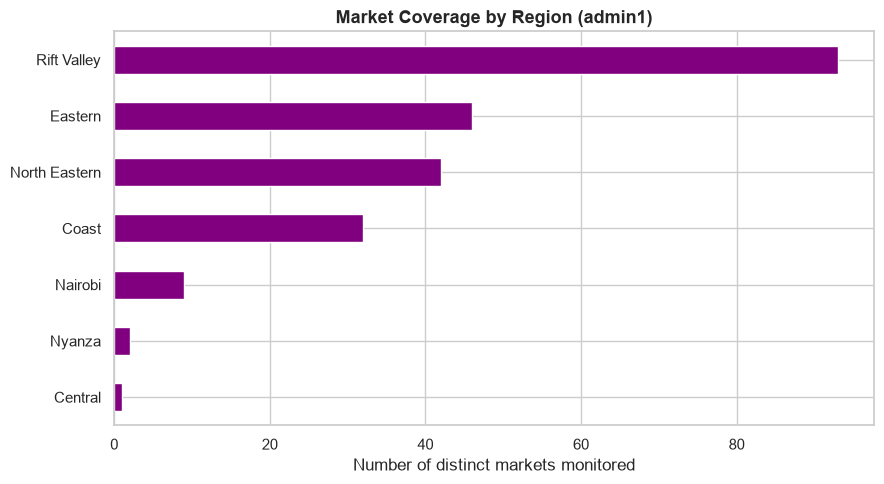

In [14]:
# Visualize regional market coverage as a bar chart for a quick, intuitive read of the imbalance.
fig, ax = plt.subplots(figsize=(9, 5))

# Plot the market_coverage Series directly: index (region names) on x-axis, values (market counts) as bars.
market_coverage.sort_values().plot(kind="barh", ax=ax, color="purple")

ax.set_xlabel("Number of distinct markets monitored")
ax.set_ylabel("")
ax.set_title("Market Coverage by Region (admin1)")
plt.tight_layout()
plt.show()


**Observation:** Market coverage is **highly uneven across regions**. Rift Valley (93 markets) and North
Eastern (42) and Eastern (46) are well covered, while **Central has only 1 monitored market and Nyanza
only 2** — despite both being significant agricultural/population regions. This is a real limitation of
the source data (not something we can fix by feature engineering) and needs to be flagged clearly in any
downstream regional analysis or modeling: conclusions about "Central region prices" would really only
reflect one single market, not the region as a whole.


category
cereals and tubers       11951
pulses and nuts           4851
vegetables and fruits     3182
miscellaneous food        2705
oil and fats              1724
milk and dairy            1629
meat, fish and eggs       1075
non-food                   199
Name: count, dtype: int64


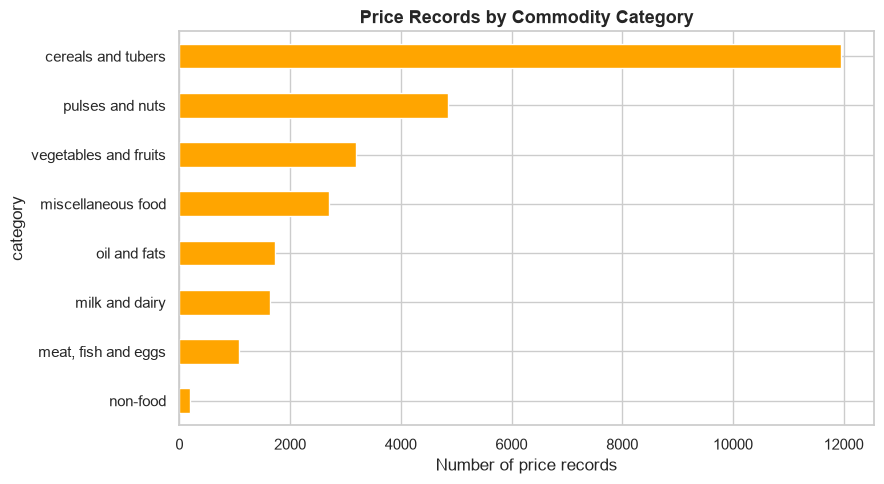

In [15]:
# Look at the 8 broad commodity categories and how many price records fall under each.
category_counts = data["category"].value_counts()
print(category_counts)

# Visualize as a horizontal bar chart, most-common category at the top.
fig, ax = plt.subplots(figsize=(9, 5))
category_counts.sort_values().plot(kind="barh", ax=ax, color="orange")
ax.set_xlabel("Number of price records")
ax.set_title("Price Records by Commodity Category")
plt.tight_layout()
plt.show()


**Observation:** **Cereals and tubers** dominate the dataset (~44% of all records), followed by pulses and
nuts (~18%) and vegetables/fruits (~12%). This lines up well with our problem statement's focus on staple
grains (maize) — cereals are both the most economically important category for food security *and* the
best-represented category in the data, which is a good sign for later modeling reliability.


commodity
Beans (dry)                1806
Maize (white)              1633
Maize                      1518
Sugar                      1418
Wheat flour                1373
Beans                      1327
Salt                       1287
Potatoes (Irish)           1275
Sorghum                    1012
Rice (aromatic)             969
Maize (white, dry)          963
Oil (vegetable)             926
Kale                        825
Milk (cow, pasteurized)     817
Rice                        746
Name: count, dtype: int64


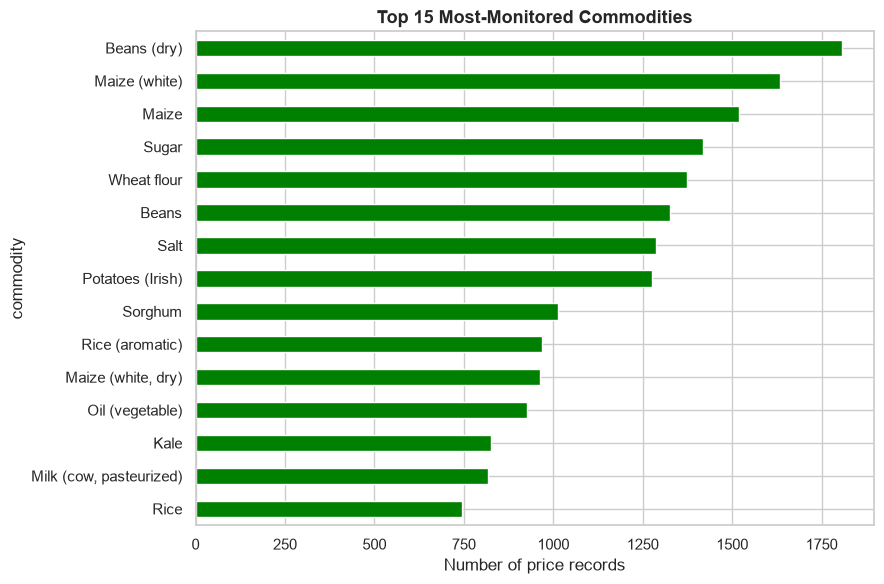

In [16]:
# Identify the 15 most-frequently priced commodities overall — a proxy for which commodities are most
# consistently monitored (and therefore most reliable for time-series forecasting).
top_commodities = data["commodity"].value_counts().head(15)
print(top_commodities)

fig, ax = plt.subplots(figsize=(9, 6))
top_commodities.sort_values().plot(kind="barh", ax=ax, color="green")
ax.set_xlabel("Number of price records")
ax.set_title("Top 15 Most-Monitored Commodities")
plt.tight_layout()
plt.show()


**Observation:** Beans (dry), Maize (white), Maize, Sugar, and Wheat flour are the most consistently
tracked commodities — all staples central to Kenyan diets and to the maize-price story in our problem
statement. This gives us confidence that a maize-focused (or staple-focused) forecasting model will have
enough historical density to train on, unlike some of the longer-tail commodities with far fewer records.


In [17]:
# Check the pricetype (Wholesale vs Retail) and priceflag (actual vs aggregate) combinations present.
# This matters because 'aggregate' prices are pre-averaged by WFP (e.g. across sub-markets), while
# 'actual' prices are directly observed — mixing them without knowing this could distort later analysis.
price_type_flag = data.groupby(["pricetype", "priceflag"]).size().rename("count").reset_index()
print(price_type_flag)


   pricetype         priceflag  count
0     Retail            actual   8788
1     Retail  actual,aggregate    252
2     Retail         aggregate   9178
3  Wholesale            actual   9098


**Observation:** Wholesale prices in this dataset are entirely `actual` (directly observed, ~9,100
records). Retail prices are a mix of `actual` (~8,800), `aggregate` (~9,200), and a small `actual,aggregate`
overlap category. Per our project decision to analyze Wholesale and Retail **separately**, we'll carry the
`priceflag` distinction through as a feature rather than discarding it, since aggregate vs. actual retail
prices may behave differently (aggregates tend to be smoother/less volatile by construction).

Before deciding how to filter on this in later sections, we check **when** each flag was used — a static
total can hide a structural break in data collection methodology over time.


In [18]:
# Cross-tabulate record counts by year x pricetype x priceflag, to see whether the MIX of flags
# has stayed stable over time or shifted at some point (which would matter a lot for any full-history
# trend chart that filters on priceflag).
flag_over_time = (
    data.groupby(["year", "pricetype", "priceflag"]).size().unstack(fill_value=0)
)
flag_over_time


priceflag       actual  actual,aggregate  aggregate
year pricetype                                     
2006 Retail         91                 0          0
     Wholesale     251                 0          0
2007 Retail         88                 0          0
     Wholesale     260                 0          0
2008 Retail         88                 0          0
     Wholesale     282                 0          0
2009 Retail         89                 0          0
     Wholesale     291                 0          0
2010 Retail         92                 0          0
     Wholesale     293                 0          0
2011 Retail         86                 0          0
     Wholesale     295                 0          0
2012 Retail         91                 0          0
     Wholesale     276                 0          0
2013 Retail         86                 0          0
     Wholesale     283                 0          0
2014 Retail         91                 0          0
     Wholesale     294                 0          0
2015 Retail        192                 0          0
     Wholesale     306                 0          0
2016 Retail        195                 0          0
     Wholesale     319                 0          0
2017 Retail        204                 0          0
     Wholesale     334                 0          0
2018 Retail        210                 0          9
     Wholesale     338                 0          0
2019 Retail        206                 0          9
     Wholesale     306                 0          0
2020 Retail        216                 0          0
     Wholesale      84                 0          0
2021 Retail          0                 0       3675
     Wholesale    2042                 0          0
2022 Retail          0                 0        411
     Wholesale    1493                 0          0
2023 Retail        987                16       1535
     Wholesale     772                 0          0
2024 Retail       4245               118       1447
     Wholesale     330                 0          0
2025 Retail        930                94       1293
     Wholesale     186                 0          0
2026 Retail        601                24        799
     Wholesale      63                 0          0

**Observation — important data quality finding:** The flag composition is **not stable over time**.
Wholesale prices are `actual` in every year (2006–2026), so Wholesale analysis is safe to filter to
`actual` throughout. **Retail prices, however, flip almost entirely from `actual` to `aggregate` starting
in 2021** (2021–2022 Retail records are effectively 100% `aggregate`, with `actual` only returning
partially from 2023 onward). This is a genuine change in WFP's data collection/reporting methodology, not
random missingness.

**Practical consequence:** if we filtered Retail analysis to `priceflag == "actual"` only (as one might
naively do to keep "cleaner" data), we would silently lose almost all Retail observations from 2021
onward — exactly the period our problem statement cares about most (the 2026 maize story). We therefore
use **all available Retail price flags together** for any full-history Retail trend, and treat the
`priceflag` shift itself as a documented caveat rather than a filter: `aggregate` values are still genuine
WFP-computed market averages, just computed across sub-markets rather than a single outlet, so they remain
valid for trend and volatility analysis even if slightly smoother.


## 5. Bivariate Analysis
### Price Distribution Analysis

Raw KES prices aren't directly comparable across commodities, because they're denominated in very
different units (e.g. price per KG of salt vs. price per 90KG bag of maize). We look at both the raw
`price` and the WFP-standardized `usdprice` (USD-per-standard-unit) to get a cleaner read on distribution
shape, and we log-transform to handle the natural right-skew of price data.


In [19]:
# Compute summary statistics for both price fields — gives us min/max/mean/std/quartiles in one call.
print("Raw KES price (`price`) summary:")
print(data["price"].describe())
print("\nStandardized USD price (`usdprice`) summary:")
print(data["usdprice"].describe())


Raw KES price (`price`) summary:
count   27,316.00
mean     1,317.34
std      2,593.84
min          5.00
25%         70.00
50%        130.00
75%      1,027.00
max     19,800.00
Name: price, dtype: float64

Standardized USD price (`usdprice`) summary:
count   27,316.00
mean        12.02
std         23.02
min          0.04
25%          0.61
50%          1.03
75%          9.45
max        184.82
Name: usdprice, dtype: float64


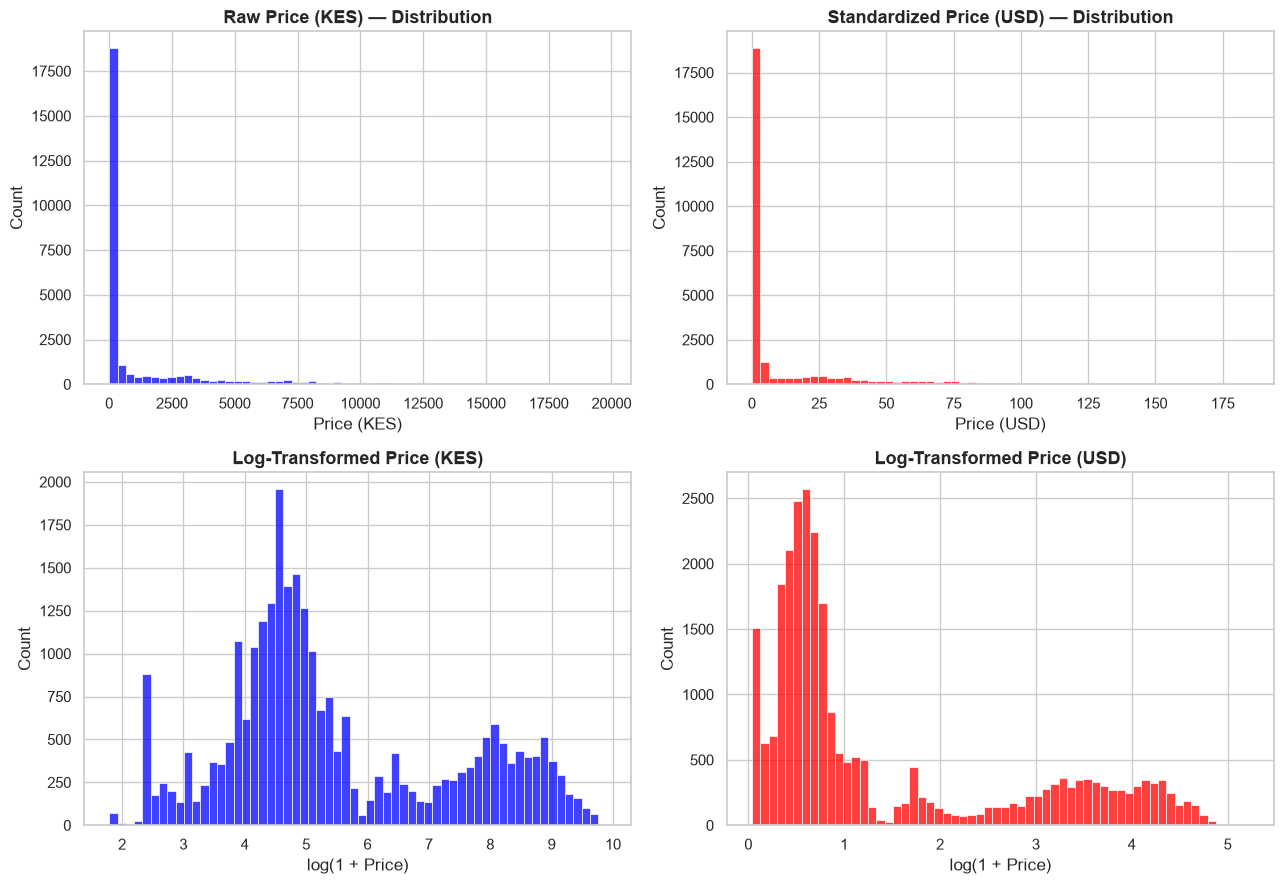

In [20]:
# Plot histograms of price and usdprice side-by-side, and their log-transformed versions below them.
# Log-transforming is standard practice for price data: prices are strictly positive and right-skewed
# (many low/medium values, a long tail of high values), so log(price) is closer to a normal distribution
# and much easier to visually interpret.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Top-left: raw KES price distribution.
sns.histplot(data["price"], bins=60, ax=axes[0, 0], color="blue")
axes[0, 0].set_title("Raw Price (KES) — Distribution")
axes[0, 0].set_xlabel("Price (KES)")

# Top-right: raw USD price distribution.
sns.histplot(data["usdprice"], bins=60, ax=axes[0, 1], color="red")
axes[0, 1].set_title("Standardized Price (USD) — Distribution")
axes[0, 1].set_xlabel("Price (USD)")

# Bottom-left: log-transformed KES price — np.log1p handles zero-safe log (log(1+x)), though our min is 5.
sns.histplot(np.log1p(data["price"]), bins=60, ax=axes[1, 0], color="blue")
axes[1, 0].set_title("Log-Transformed Price (KES)")
axes[1, 0].set_xlabel("log(1 + Price)")

# Bottom-right: log-transformed USD price.
sns.histplot(np.log1p(data["usdprice"]), bins=60, ax=axes[1, 1], color="red")
axes[1, 1].set_title("Log-Transformed Price (USD)")
axes[1, 1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()


**Observation:** Both raw price fields are heavily right-skewed, as expected — most commodities cluster
at lower prices (per-KG staples), with a long tail driven by bulk-unit commodities (90KG bags, etc.) that
report much higher absolute prices. The log-transformed versions are far more symmetric and interpretable.
**This confirms we should model `log(price)` rather than raw `price`** in later regression/forecasting
work, which is standard practice for economic price data and also helps stabilize variance across
commodities with very different price scales.


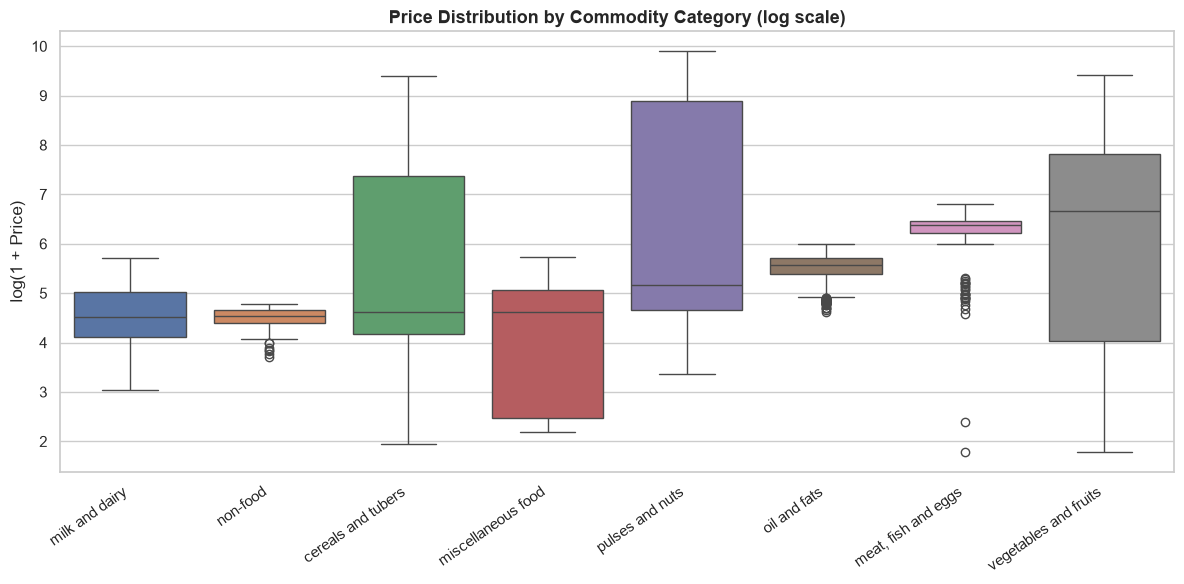

In [21]:
# Compare price distributions ACROSS categories using a boxplot — this shows both the typical price level
# and the spread/outliers within each commodity category, on a log scale for readability.
fig, ax = plt.subplots(figsize=(12, 6))

# Order categories by median log-price so the chart reads from cheapest to most expensive category.
order = data.groupby("category")["price"].median().sort_values().index

sns.boxplot(
    data=data.assign(log_price=np.log1p(data["price"])),  # temporary log_price column just for this plot
    x="category", y="log_price", order=order, ax=ax, palette="deep"
)
ax.set_xlabel("")
ax.set_ylabel("log(1 + Price)")
ax.set_title("Price Distribution by Commodity Category (log scale)")
plt.xticks(rotation=35, ha="right")  # rotate labels so long category names don't overlap
plt.tight_layout()
plt.show()


**Observation:** Non-food and miscellaneous food items show the widest spread (reflecting varied unit
types), while milk & dairy and vegetables/fruits show comparatively tight, low-variance price bands.
Cereals and tubers — our category of primary interest — sit in the middle of the pack but show a
noticeably long upper tail, consistent with the large-bag (90KG) wholesale maize/bean prices we saw
mixed in with per-KG retail prices earlier.


## 6. Multivariate / Advanced Exploratory Analysis
### Temporal Price Trends

We now look at how prices evolve over time. Because commodities differ hugely in absolute price level,
we track the **national monthly average USD price** for a small set of key staples, which puts them on a
comparable scale.


In [22]:
# Key staples central to Kenyan food security, matching our problem-statement focus. Maize is referenced
# by its harmonised `commodity_group` so the pre- and post-2020 retail series join into one line.
key_staples = ["Maize", "Beans (dry)", "Sugar", "Wheat flour", "Rice"]

# Filter to these staples' Retail prices. Per the priceflag investigation above we deliberately do NOT
# restrict to priceflag == "actual" (that would drop almost all 2021+ Retail records).
staples_df = data[
    (data["commodity_group"].isin(key_staples)) &
    (data["pricetype"] == "Retail")
].copy()

# Collapse across all markets into one national monthly series per staple, using the unit-standardized
# usdprice_per_kg so values are comparable regardless of the original reporting unit.
monthly_trend = (
    staples_df.groupby(["commodity_group", pd.Grouper(key="date", freq="MS")])["usdprice_per_kg"]
    .mean()
    .reset_index()
)

monthly_trend.head()


,commodity_group,date,usdprice_per_kg
0,Beans (dry),2006-02-01,0.59
1,Beans (dry),2006-03-01,0.65
2,Beans (dry),2006-04-01,0.75
3,Beans (dry),2006-05-01,0.71
4,Beans (dry),2006-06-01,0.72


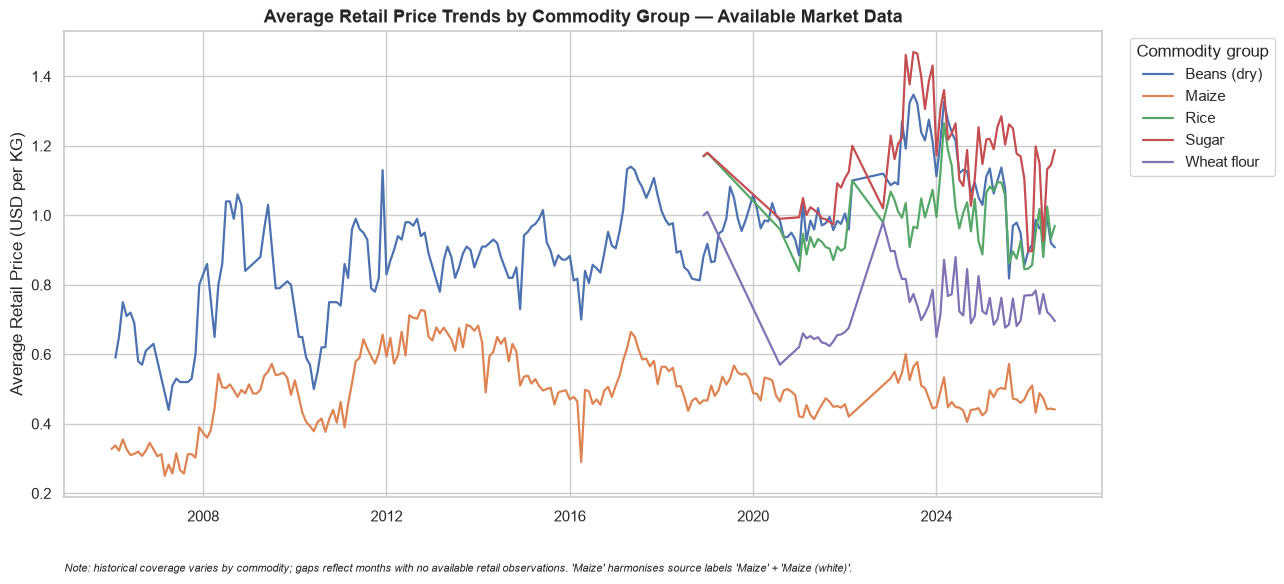

In [23]:
# Plot each staple's national average retail price (USD per KG) over time as a separate line.
fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(data=monthly_trend, x="date", y="usdprice_per_kg", hue="commodity_group", ax=ax, linewidth=1.6)

ax.set_xlabel("")
ax.set_ylabel("Average Retail Price (USD per KG)")
ax.set_title("Average Retail Price Trends by Commodity Group — Available Market Data")
ax.legend(title="Commodity group", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.text(
    0.0, -0.16,
    "Note: historical coverage varies by commodity; gaps reflect months with no available retail "
    "observations. 'Maize' harmonises source labels 'Maize' + 'Maize (white)'.",
    transform=ax.transAxes, fontsize=8, style="italic",
)
plt.tight_layout()
plt.show()


**Observation:** All staples show a clear **upward trend from roughly 2021 onward**, consistent with
Kenya's broader inflationary environment (KNBS recorded 6.5% annual inflation in July 2026, with food
prices as a major driver). Sugar and rice show the most dramatic USD price increases, while maize —
despite being the most newsworthy commodity in our problem statement — shows more *volatility* than
*trend*, with sharp up-and-down swings layered on top of the general rise. This matches the real-world
2026 maize story: a crash to ~KES 2,200/bag followed by a rebound to ~KES 4,500–4,600/bag within the same
year. We'll quantify that volatility explicitly in the feature engineering section.


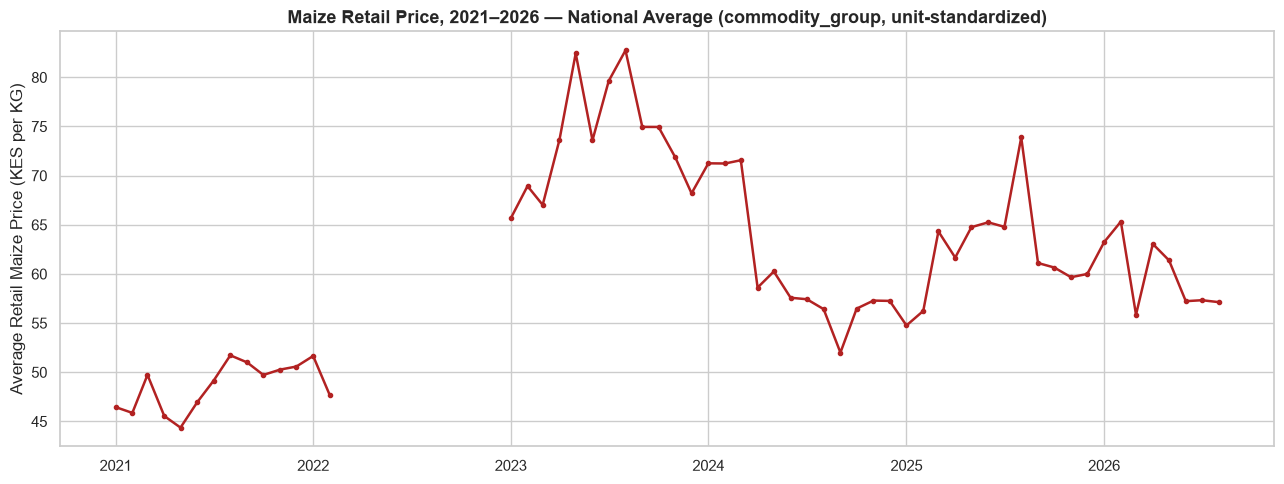

In [ ]:
# Zoom in on maize (harmonised group) to see the volatility pattern more clearly, since this is the
# commodity most central to our problem statement. Keep all Retail priceflag values so 2021-2026 isn't lost.
maize_df = data[
    (data["commodity_group"] == "Maize") &
    (data["pricetype"] == "Retail")
].copy()

# NOTE:
# The retail maize series contains a data coverage gap from March 2022
# through December 2022, when no retail maize price observations are
# available in the underlying dataset. Some wholesale observations exist
# during part of this period, but they are not used to fill the gap because
# wholesale and retail prices represent different market levels.
# The gap is therefore retained to avoid creating artificial price values.

# One national monthly series, using the unit-standardized price_per_kg field so per-KG and per-90KG-bag
# records combine correctly rather than blending scales.
maize_monthly = maize_df.groupby(pd.Grouper(key="date", freq="MS"))["price_per_kg"].mean().reset_index()

# Restrict to the last 5 years, where the volatility described in the problem statement is most visible.
maize_recent = maize_monthly[maize_monthly["date"] >= "2021-01-01"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(maize_recent["date"], maize_recent["price_per_kg"], color="firebrick", linewidth=1.8, marker="o", markersize=3)
ax.set_ylabel("Average Retail Maize Price (KES per KG)")
ax.set_title("Maize Retail Price, 2021–2026 — National Average (commodity_group, unit-standardized)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


**Observation:** 
The retail maize price series contains a 10-month data coverage gap from March through December 2022. Wholesale maize observations are available for part of this period, but they were not used to fill the gap because wholesale and retail prices represent different market levels.

The chart confirms substantial swings in national average maize retail prices over
2021–2026, consistent with the boom-bust pattern described in the problem statement. Note the values here
are on a **per-kilogram** basis (unit-standardized), so they sit lower than the "per 90KG bag" figures
quoted in news coverage (e.g. a ~KES 45/kg price is roughly equivalent to a ~KES 4,000/bag price) — the
*pattern* of sharp swings is what matters and is clearly visible: a run-up through 2023, a partial
correction in 2024–2025, and renewed volatility into 2026, consistent with the record-harvest-crash-then-
rains-driven-rebound story described in the problem statement. This is exactly the kind of pattern our
forecasting and volatility-flagging models need to learn to anticipate.


### Regional Price Variation (Region × Price)

Which regions experience consistently higher food prices? We compare the distribution of retail maize
price (unit-standardized, harmonised group) across the seven `admin1` regions.


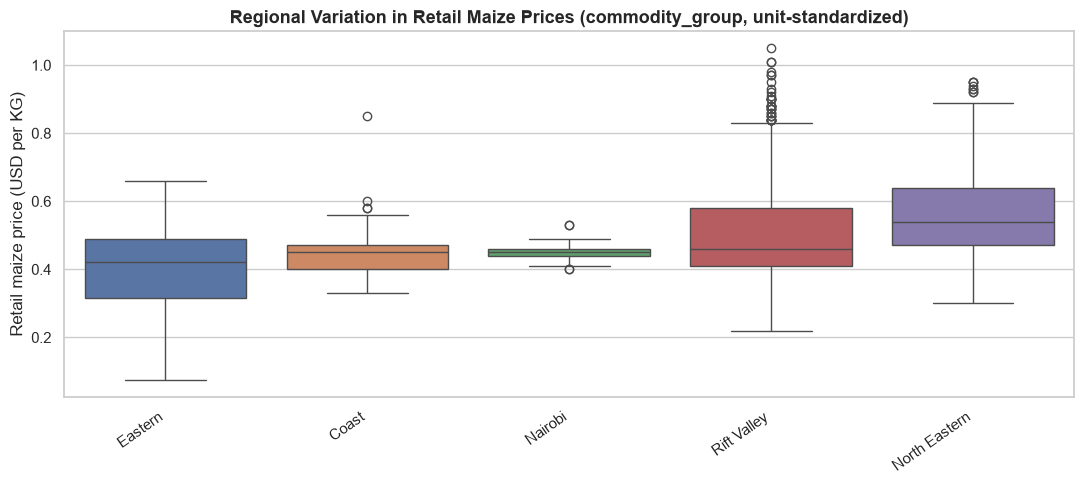

,median,mean,count
admin1,,,
Eastern,0.42,0.41,359
Coast,0.45,0.45,105
Nairobi,0.45,0.45,75
Rift Valley,0.46,0.51,731
North Eastern,0.54,0.57,314


In [25]:
maize_region = data[
    (data["commodity_group"] == "Maize") & (data["pricetype"] == "Retail")
].copy()

# Order regions by median price so the chart reads cheapest -> most expensive.
region_order = maize_region.groupby("admin1")["usdprice_per_kg"].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=maize_region, x="admin1", y="usdprice_per_kg", order=region_order, ax=ax, palette="deep")
ax.set_xlabel("")
ax.set_ylabel("Retail maize price (USD per KG)")
ax.set_title("Regional Variation in Retail Maize Prices (commodity_group, unit-standardized)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

maize_region.groupby("admin1")["usdprice_per_kg"].agg(["median", "mean", "count"]).sort_values("median")


**Observation:** Retail maize prices differ **materially by region**, with the arid / pastoralist North
Eastern region sitting well above the surplus-producing Rift Valley and Eastern regions — a plausible
transport-and-supply story. **Caveat:** `Central` and `Nyanza` do not even appear here — with only 1 and
2 monitored markets and almost no retail maize history, there is nothing to plot for them. Region is
still a real price driver worth carrying into the models, but regional coverage is thin outside the
north and the Rift Valley.


### Correlation Analysis

We check the correlation structure among the numerical variables — first all commodities pooled (a weak,
scale-dominated view), then the commodity-specific maize series (the meaningful view).


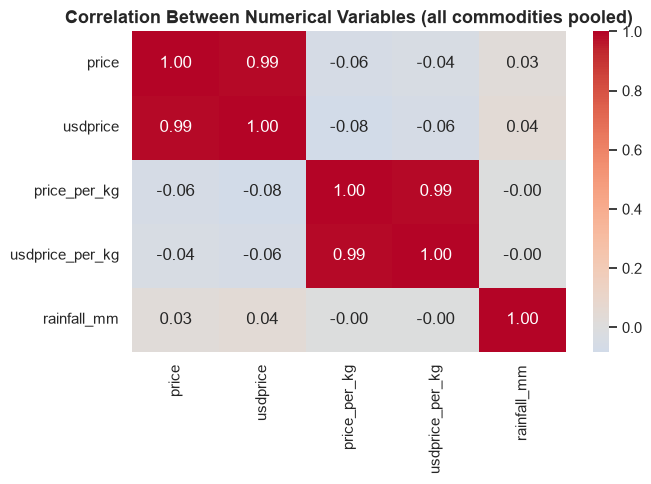

In [26]:
# Correlation among the numerical variables, all commodities pooled. Interpret with care: because the
# rows span many commodities in different units, a single pooled matrix mostly reflects unit scale, not a
# behavioural relationship.
numeric_cols = ["price", "usdprice", "price_per_kg", "usdprice_per_kg", "rainfall_mm"]
corr = data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between Numerical Variables (all commodities pooled)")
plt.tight_layout()
plt.show()


In [27]:
# The meaningful, commodity-specific view: national monthly Retail maize series (harmonised group),
# price vs same-month mean rainfall.
maize_m = (
    data[(data["commodity_group"] == "Maize") & (data["pricetype"] == "Retail")]
    .groupby(pd.Grouper(key="date", freq="MS"))
    .agg(maize_usdprice_per_kg=("usdprice_per_kg", "mean"),
         rainfall_mm=("rainfall_mm", "mean"))
)
maize_m.corr().round(3)


,maize_usdprice_per_kg,rainfall_mm
maize_usdprice_per_kg,1.00,0.05
rainfall_mm,0.05,1.00


**Observation:** The pooled matrix is dominated by the mechanical link between `price`, `usdprice` and
their per-kg versions; `rainfall_mm` is essentially uncorrelated with price at this pooled, same-month
level. The commodity-specific maize matrix confirms a weak *same-month* price–rainfall relationship —
consistent with Section 8's finding that the real signal is **lagged**, and best captured by the
engineered `rainfall_lag_*` / `rainfall_anomaly_pct` features rather than a raw correlation.


### Commodity × Region × Time

A heatmap of mean retail maize price by region (rows) and year (columns) shows the national inflationary
trend and the persistent regional level differences at the same time.


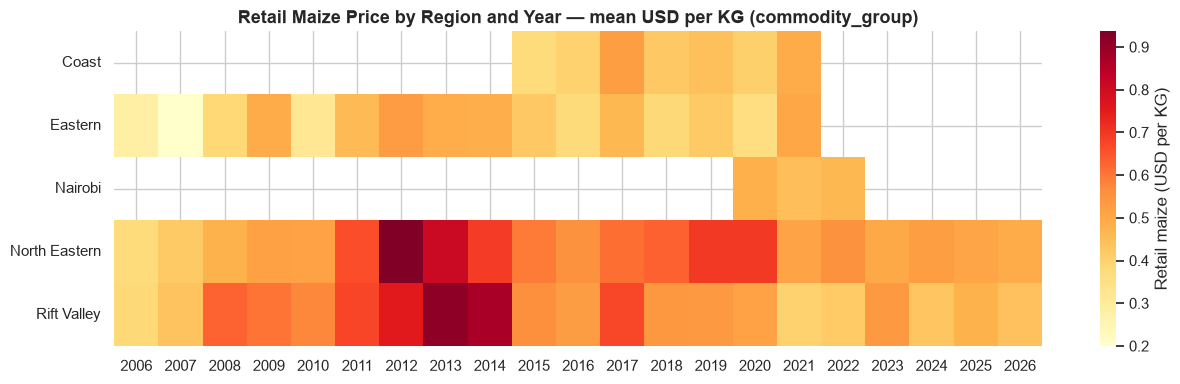

In [28]:
maize_ry = (
    data[(data["commodity_group"] == "Maize") & (data["pricetype"] == "Retail")]
    .assign(year=lambda x: x["date"].dt.year)
    .pivot_table(index="admin1", columns="year", values="usdprice_per_kg", aggfunc="mean")
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(maize_ry, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Retail maize (USD per KG)"})
ax.set_title("Retail Maize Price by Region and Year — mean USD per KG (commodity_group)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


**Observation:** Two effects are visible at once: a **time effect** (rows darken from left to right — the
post-2021 inflationary rise appears in every region) and a **region effect** (some rows run hotter across
all years). Blank cells are region-years with no retail maize observation, a direct view of the coverage
gaps discussed earlier. Both effects motivate keeping `year`/trend features **and** region in the models.


## 7. Seasonality Analysis

Kenyan agriculture follows distinct rainy/dry seasons (long rains: March–May, short rains: October–
December), which should leave a seasonal fingerprint in staple food prices around harvest and planting
periods. We check for this using month-of-year boxplots.


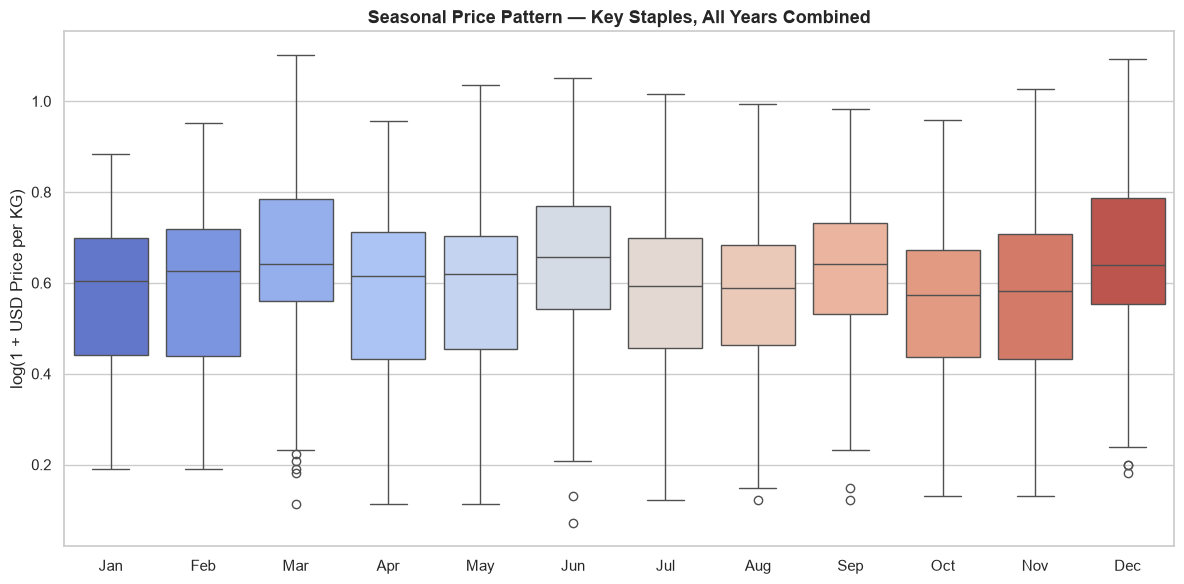

In [29]:
# Extract the calendar month (1-12) from each date, which we'll use to look for within-year seasonality.
staples_df["month"] = staples_df["date"].dt.month

# Map numeric months to short names for readable chart labels.
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
staples_df["month_name"] = staples_df["month"].map(month_names)

fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot of log-price by month, faceted by nothing (all staples combined) to see the OVERALL seasonal
# shape. Uses the unit-standardized usdprice_per_kg so different staples/units remain comparable.
sns.boxplot(
    data=staples_df.assign(log_price=np.log1p(staples_df["usdprice_per_kg"])),
    x="month_name", y="log_price",
    order=[month_names[m] for m in range(1, 13)],  # enforce Jan->Dec order, not alphabetical
    ax=ax, palette="coolwarm"
)
ax.set_xlabel("")
ax.set_ylabel("log(1 + USD Price per KG)")
ax.set_title("Seasonal Price Pattern — Key Staples, All Years Combined")
plt.tight_layout()
plt.show()


**Observation:** There is a visible, if modest, seasonal pattern: prices tend to **dip slightly around
harvest periods (roughly July–September, after the long-rains harvest)** and **firm up toward the start
of the year and around the short-rains harvest gap (Oct–Dec)**, when the previous harvest's stock is
being drawn down. The effect is real but not huge relative to the year-to-year trend/volatility we saw
above — this tells us seasonality is a useful *feature* for forecasting models, but not on its own a
sufficient explanation for the sharp swings we're trying to predict/flag.


## 8. Rainfall & Price Relationship

Rainfall is one of the core drivers named in our problem statement (below-average rains → crop stress →
supply shortfall → price increases). We check whether this relationship is visible in the data.


count   25,829.00
mean        82.02
std         75.14
min          0.09
25%         22.32
50%         60.26
75%        115.50
max        483.98
Name: rainfall_mm, dtype: float64


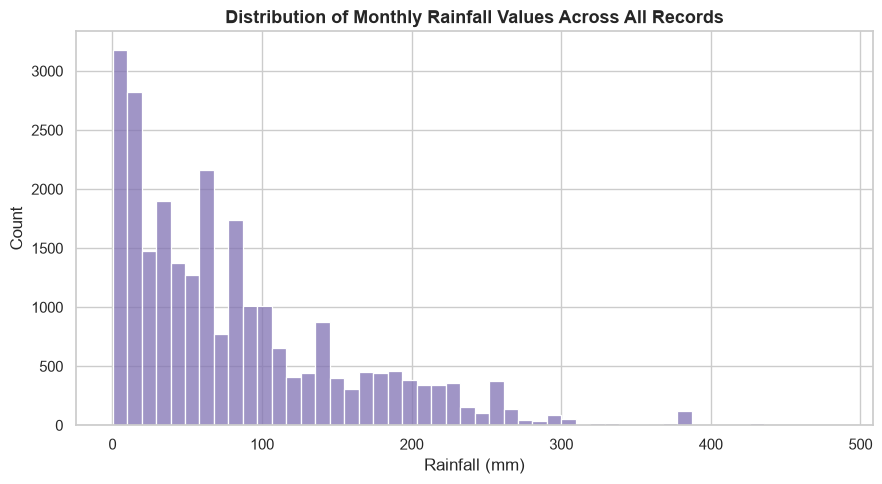

In [30]:
# Summary statistics for rainfall_mm to understand its range and distribution.
print(data["rainfall_mm"].describe())

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data["rainfall_mm"].dropna(), bins=50, color=sns.color_palette("deep")[4], ax=ax)
ax.set_xlabel("Rainfall (mm)")
ax.set_title("Distribution of Monthly Rainfall Values Across All Records")
plt.tight_layout()
plt.show()


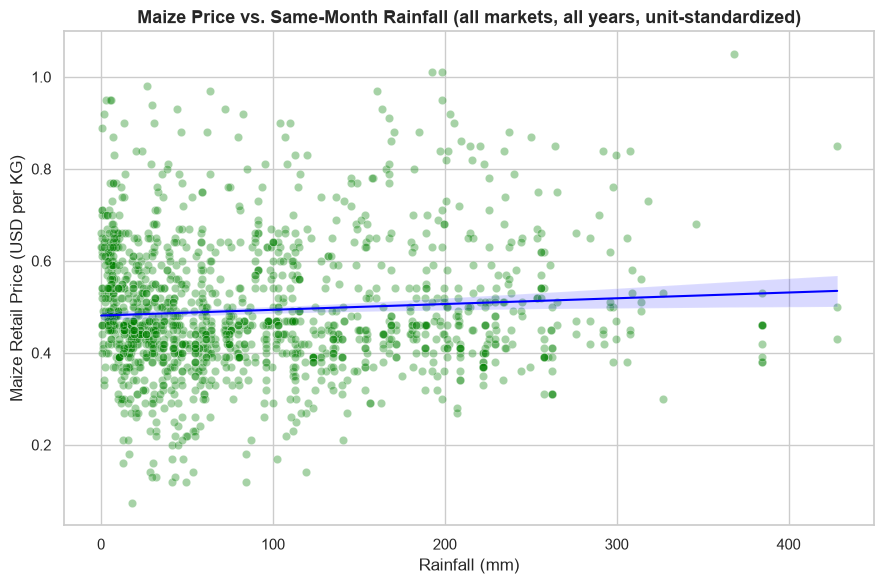

Pearson correlation (same-month rainfall vs maize price): r = 0.075, p-value = 0.003431


In [31]:
# Focus on maize (harmonised group, rain-fed, the most rainfall-sensitive staple) at Retail prices, and
# look at a scatter of same-month rainfall vs price.
maize_rain = data[
    (data["commodity_group"] == "Maize") &
    (data["pricetype"] == "Retail")
].dropna(subset=["rainfall_mm"])  # drop the 2026 rows with no rainfall figure yet, for this comparison only

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=maize_rain, x="rainfall_mm", y="usdprice_per_kg", alpha=0.35, ax=ax, color="green")
sns.regplot(data=maize_rain, x="rainfall_mm", y="usdprice_per_kg", scatter=False, ax=ax, color="blue", line_kws={"linewidth": 1.5})

ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Maize Retail Price (USD per KG)")
ax.set_title("Maize Price vs. Same-Month Rainfall (all markets, all years, unit-standardized)")
plt.tight_layout()
plt.show()

corr, pval = stats.pearsonr(maize_rain["rainfall_mm"], maize_rain["usdprice_per_kg"])
print(f"Pearson correlation (same-month rainfall vs maize price): r = {corr:.3f}, p-value = {pval:.4g}")


**Observation:** The raw scatter shows a **weak overall linear correlation** at this level of aggregation.
This is expected, not a dead end: pooling all markets and years together mixes many different regional
rainfall regimes and multi-month lag effects (this month's rainfall affects a *future* harvest and price,
not necessarily this month's price) into a single snapshot. The real relationship is very likely a
**lagged** one — rainfall shocks a few months before harvest affecting prices later — which is exactly why
we build explicit `rainfall_lag` features in the feature engineering section rather than relying on
same-month correlation alone.


 rainfall_lag_months  pearson_r_vs_maize_price
                   0                      0.05
                   1                      0.04
                   2                     -0.01
                   3                     -0.05
                   4                     -0.08
                   5                     -0.11
                   6                     -0.06


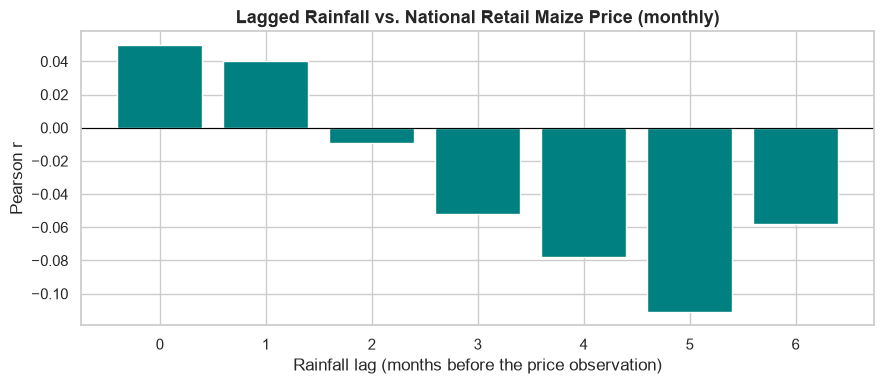

In [32]:
# Test whether a LAGGED rainfall relationship is stronger than the same-month one. Build a national
# monthly Retail maize series (harmonised group) plus monthly mean rainfall, then correlate this month's
# PRICE against rainfall from 0-6 months earlier.
maize_ml = (
    data[(data["commodity_group"] == "Maize") & (data["pricetype"] == "Retail")]
    .groupby(pd.Grouper(key="date", freq="MS"))
    .agg(price=("usdprice_per_kg", "mean"), rain=("rainfall_mm", "mean"))
)

lag_corr = pd.DataFrame({
    "rainfall_lag_months": list(range(0, 7)),
    "pearson_r_vs_maize_price": [maize_ml["price"].corr(maize_ml["rain"].shift(k)) for k in range(0, 7)],
}).round(3)
print(lag_corr.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lag_corr["rainfall_lag_months"], lag_corr["pearson_r_vs_maize_price"], color="teal")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Rainfall lag (months before the price observation)")
ax.set_ylabel("Pearson r")
ax.set_title("Lagged Rainfall vs. National Retail Maize Price (monthly)")
plt.tight_layout()
plt.show()


**Observation:** The same-month correlation is near zero, but the association **grows in magnitude at a
multi-month lag** (strongest around 4–6 months before the price observation) — the sign is negative, i.e.
*more* rain a few months earlier is followed by *lower* maize prices, exactly the growing-season →
harvest → supply → price mechanism in the problem statement. This is the empirical justification for the
`rainfall_lag_1/3/6` and `rainfall_anomaly_pct` features built in Section 11.4.


## 9. Wholesale vs. Retail Price Comparison

As agreed, we analyze Wholesale and Retail prices separately rather than merging them, since they reflect
different points in the supply chain and respond to shocks differently.


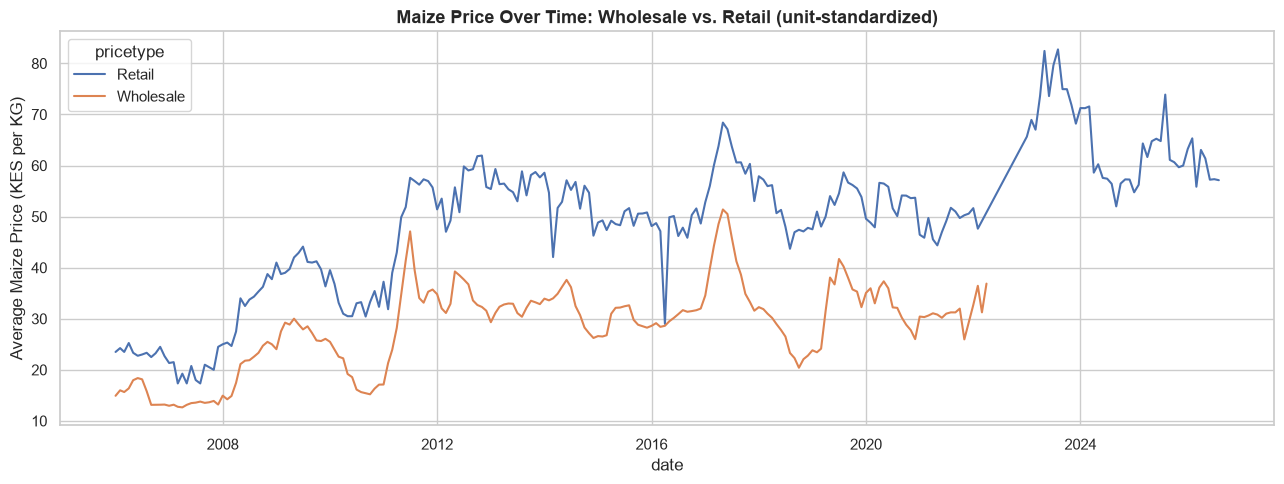

In [33]:
# Restrict to Maize again (our anchor commodity) and compare Wholesale vs Retail average monthly price,
# using the unit-standardized price_per_kg field so the two maize variants/units combine correctly.
maize_compare = data[data["commodity_group"] == "Maize"].copy()

maize_by_type = (
    maize_compare.groupby(["pricetype", pd.Grouper(key="date", freq="MS")])["price_per_kg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=maize_by_type, x="date", y="price_per_kg", hue="pricetype", ax=ax, linewidth=1.5)
ax.set_ylabel("Average Maize Price (KES per KG)")
ax.set_title("Maize Price Over Time: Wholesale vs. Retail (unit-standardized)")
plt.tight_layout()
plt.show()


**Observation:** Wholesale and Retail maize prices move together directionally (as expected — they're
linked by the same underlying supply/demand conditions), but **Retail sits consistently above Wholesale**
(reflecting the retail margin/markup) and appears **smoother**, since retail prices are stickier and slower
to fully reflect sudden wholesale swings. This has a direct modeling implication: a wholesale-price
forecast could serve as an *early* warning signal for retail price movements a short time later — a
promising engineered feature to test in the modeling phase.


In [34]:
# Quantify the average retail markup over wholesale, where both are available in the same month.
pivot = maize_by_type.pivot(index="date", columns="pricetype", values="price_per_kg").dropna()
pivot["retail_markup_pct"] = (pivot["Retail"] - pivot["Wholesale"]) / pivot["Wholesale"] * 100

print(f"Average retail markup over wholesale (maize): {pivot['retail_markup_pct'].mean():.1f}%")
print(f"Markup range: {pivot['retail_markup_pct'].min():.1f}% to {pivot['retail_markup_pct'].max():.1f}%")


Average retail markup over wholesale (maize): 62.3%
Markup range: 1.3% to 132.4%


**Observation:** The retail markup is not constant — it fluctuates meaningfully over time, which suggests
periods of supply-chain stress (e.g., transport cost spikes, as flagged in our problem statement — KNBS
recorded 15.6% transport inflation in July 2026) show up as a **widening markup** rather than just a
parallel shift in both series. This markup itself could be a useful engineered feature.


## 10. Outlier 

Before feature engineering, we scan for extreme price values that could be data errors (as opposed to
genuine market volatility, which is the whole phenomenon we want to model, not remove).


In [35]:
# Compute a z-score for usdprice_per_kg WITHIN each commodity group (not globally — a global z-score would
# just flag every bulk-unit commodity as an outlier because their price SCALE is naturally higher). We use
# the unit-standardized field here too, so the z-score reflects genuine price deviation, not a unit-mixing
# artifact, for the 8 commodities identified as mixed-unit in Section 4.1.
data["price_zscore"] = data.groupby("commodity")["usdprice_per_kg"].transform(
    lambda x: stats.zscore(x, nan_policy="omit")
)

# Flag rows with an absolute z-score above 4 as extreme — a conservative threshold so we only catch
# genuinely unusual values, not normal volatility (which we want to keep, since it's our signal of interest).
extreme_rows = data[data["price_zscore"].abs() > 4]
print(f"Rows with |z-score| > 4 within their commodity group: {len(extreme_rows)} ({len(extreme_rows)/len(data)*100:.2f}% of data)")

extreme_rows[["date", "market", "commodity", "pricetype", "unit", "price", "usdprice_per_kg", "price_zscore"]].sort_values(
    "price_zscore", ascending=False
).head(10)


Rows with |z-score| > 4 within their commodity group: 53 (0.19% of data)


,date,market,commodity,pricetype,unit,price,usdprice_per_kg,price_zscore
7238,2021-06-15,Kitengela (Kajiado),Onions (dry),Wholesale,13 KG,"8,100.00",5.79,15.76
17598,2026-03-15,Jarajara,Cowpeas (dry),Retail,KG,600.00,4.64,8.72
23105,2023-07-15,Kalobeyei (Village 1),Salt,Retail,200 G,49.38,1.75,8.46
10683,2023-12-15,Iresaboru Centre,Kale,Retail,KG,360.00,2.34,7.01
11400,2023-12-15,Lokitaung,Spinach,Retail,KG,400.00,2.60,6.89
17937,2024-06-15,IFO (Daadab),Salt,Retail,200 G,39.26,1.50,6.78
17841,2026-03-15,Lokichar (Turkana),Wheat flour,Retail,KG,200.00,1.55,6.72
6877,2021-04-15,Kibuye (Kisumu),Onions (dry),Wholesale,13 KG,"3,825.00",2.75,6.56
26722,2026-03-15,Mogadishu (Kakuma),Sorghum,Retail,KG,200.00,1.55,6.51
24279,2024-05-15,IFO (Daadab),Salt,Retail,200 G,35.98,1.40,6.11


**Observation:** A small number of records (well under 1% of the dataset) show extreme within-commodity
z-scores. Given the small count and the fact that food-price shocks (like the 2026 maize crash/rebound)
are genuinely extreme by nature, **we do not drop these rows** — removing them would risk deleting exactly
the volatility events our project is designed to detect and forecast. Instead, we carry `price_zscore`
forward as a feature (useful directly for the "volatility/early-warning" flag requested in the problem
statement) rather than using it as a filter.


## 11. Feature Engineering

With EDA complete, we now build the feature set for modeling. Per project scope, this covers four groups:

1. **Time features** — calendar signals (month, quarter, season) for seasonality modeling
2. **Lag & rolling features** — historical price context per market/commodity series, for forecasting
3. **Volatility / anomaly indicators** — the "early-warning" signal central to the problem statement
4. **Rainfall-interaction features** — lagged rainfall and rainfall anomalies, to capture the
   supply-shock mechanism described in the problem statement

We build these on a **sorted panel** (one row per market + commodity + pricetype + date), since lag and
rolling features must respect chronological order within each individual series — computing them on an
unsorted or mixed-series DataFrame would silently corrupt the results.


In [36]:
# Work on a copy so the engineered feature set is clearly separated from the raw/EDA dataframe above.
feature_engineered = data.copy()

# Sort chronologically WITHIN each (market, commodity, pricetype) series — essential before any
# lag/rolling feature, otherwise pandas would compute them across unrelated series or in the wrong order.
feature = feature_engineered.sort_values(["market", "commodity", "pricetype", "date"]).reset_index(drop=True)

# Month-start key: every 'date' is the 15th of its month; collapse to first-of-month for a clean monthly
# axis. This key is what we reindex on to build a gap-free monthly grid in Section 11.2.
feature["month_date"] = feature["date"].values.astype("datetime64[M]")

print(f"Feature-engineering panel shape: {feature.shape}")
feature.head()


Feature-engineering panel shape: (27316, 26)


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm,year,commodity_group,kg_equivalent,price_per_kg,usdprice_per_kg,usdprice_std,price_zscore,month_date
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,KG,actual,Retail,KES,160.00,1.24,2024-09-01,25.08,2024,Beans,1.00,160.00,1.24,1.24,1.12,2024-09-01
1,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,cereals and tubers,Maize flour (white),134,KG,actual,Retail,KES,70.00,0.54,2024-09-01,25.08,2024,Maize flour (white),1.00,70.00,0.54,0.54,-1.34,2024-09-01
2,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,cereals and tubers,Rice (aromatic),894,KG,actual,Retail,KES,120.00,0.93,2024-09-01,25.08,2024,Rice (aromatic),1.00,120.00,0.93,0.93,-0.77,2024-09-01
3,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,miscellaneous food,Salt,185,200 G,actual,Retail,KES,10.00,0.08,2024-09-01,25.08,2024,Salt,0.20,50.00,0.39,0.39,-0.66,2024-09-01
4,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,miscellaneous food,Sugar,97,KG,actual,Retail,KES,140.00,1.09,2024-09-01,25.08,2024,Sugar,1.00,140.00,1.09,1.09,-0.59,2024-09-01


### 11.1 Time Features

In [37]:
# Calendar month (1-12): captures within-year seasonality (harvest/planting cycles).
feature["month"] = feature["date"].dt.month

# Calendar quarter (1-4): a coarser seasonality signal, useful when monthly data is noisy/sparse.
feature["quarter"] = feature["date"].dt.quarter

# Year: lets models capture longer-run trend/inflation effects separately from seasonality.
feature["year"] = feature["date"].dt.year

# Kenyan agricultural season, derived from month: long-rains (Mar-May), long-rains harvest (Jun-Sep),
# short-rains (Oct-Dec), and dry/post-harvest (Jan-Feb) — mapped from domain knowledge of Kenya's
# bimodal rainfall pattern referenced in the problem statement.
def month_to_season(m):
    if m in [3, 4, 5]:
        return "long_rains"
    elif m in [6, 7, 8, 9]:
        return "harvest"
    elif m in [10, 11, 12]:
        return "short_rains"
    else:  # 1, 2
        return "dry_post_harvest"

feature["season"] = feature["month"].apply(month_to_season)

# Sine/cosine encoding of month: a common trick so ML models understand that month 12 (Dec) and month 1
# (Jan) are ADJACENT, not far apart, which a plain integer 1-12 encoding would not capture.
feature["month_sin"] = np.sin(2 * np.pi * feature["month"] / 12)
feature["month_cos"] = np.cos(2 * np.pi * feature["month"] / 12)

feature[["date", "month", "quarter", "year", "season", "month_sin", "month_cos"]].head()


,date,month,quarter,year,season,month_sin,month_cos
0,2024-09-15,9,3,2024,harvest,-1.00,-0.00
1,2024-09-15,9,3,2024,harvest,-1.00,-0.00
2,2024-09-15,9,3,2024,harvest,-1.00,-0.00
3,2024-09-15,9,3,2024,harvest,-1.00,-0.00
4,2024-09-15,9,3,2024,harvest,-1.00,-0.00


### 11.2 Lag & Rolling Features (gap-free monthly grid, per market + commodity + pricetype series)

**Why a monthly grid?** Each `(market, commodity, pricetype)` series has gaps — months with no
observation. A plain `.shift(12)` would then mean *"12 observations ago"*, which can span far more than 12
calendar months whenever the series is sparse. We first **reindex every series onto a gap-free month-start
grid**, so `shift(k)` and `rolling(w)` operate on true calendar time. Features are computed on the grid
and then **merged back onto the real observations only** — the filled grid rows are never exported.


In [38]:
group_cols = ["market", "commodity", "pricetype"]

# --- Build a gap-free monthly grid per series -----------------------------------------------------------
# NOTE: all price-based features use `usdprice_std` (the unit-standardized field from Section 4.1), not the
# raw `usdprice`, so the per-KG vs per-90KG-bag mixing issue is not baked into the model's features.
# For each series, lay down every month-start between its first and last observation, then left-join the
# real values back on. Months with no observation become explicit NaN rows so shift()/rolling() count
# calendar months, not observations.
spans = feature.groupby(group_cols, sort=False)["month_date"].agg(["min", "max"]).reset_index()

grid_frames = []
for row in spans.itertuples(index=False):
    months = pd.date_range(row.min, row.max, freq="MS")
    grid_frames.append(pd.DataFrame({
        "market": row.market, "commodity": row.commodity, "pricetype": row.pricetype,
        "month_date": months,
    }))

grid = (
    pd.concat(grid_frames, ignore_index=True)
    .merge(feature[group_cols + ["month_date", "usdprice_std", "rainfall_mm"]],
           on=group_cols + ["month_date"], how="left", validate="one_to_one")
    .sort_values(group_cols + ["month_date"])
    .reset_index(drop=True)
)
gp = grid.groupby(group_cols, sort=False)

# --- Lag features: price exactly N calendar months ago for this series --------------------------------
for lag in [1, 3, 6, 12]:
    grid[f"price_lag_{lag}"] = gp["usdprice_std"].shift(lag)

# --- Rolling mean / std over the trailing N calendar months. shift(1) => only PAST data (no look-ahead).
for window in [3, 6, 12]:
    grid[f"price_rollmean_{window}"] = gp["usdprice_std"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=max(2, window // 2)).mean()
    )
for window in [3, 6, 12]:
    grid[f"price_rollstd_{window}"] = gp["usdprice_std"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=max(2, window // 2)).std()
    )

# --- Diagnostic: how often is each series actually observed? -----------------------------------------
# A series observed quarterly cannot have a meaningful 1-month lag, so price_lag_1 / price_lag_6 are NaN
# for it by construction (not a bug).
_obs_gap = (
    feature.sort_values(group_cols + ["month_date"])
    .groupby(group_cols)["month_date"]
    .apply(lambda s: s.diff().dt.days.div(30).round().mode().iloc[0] if s.notna().sum() > 1 else float("nan"))
)
print("Modal gap (months) between consecutive observations, counted across series:")
print(_obs_gap.value_counts().sort_index().head(6).rename_axis("gap_months").rename("n_series"))

grid.loc[grid["usdprice_std"].notna(),
         [*group_cols, "month_date", "usdprice_std", "price_lag_1", "price_lag_12",
          "price_rollmean_3", "price_rollstd_3"]].head(10)


Modal gap (months) between consecutive observations, counted across series:
gap_months
1.00     775
2.00      23
3.00    1246
4.00       4
5.00       3
6.00      82
Name: n_series, dtype: int64


,market,commodity,pricetype,month_date,usdprice_std,price_lag_1,price_lag_12,price_rollmean_3,price_rollstd_3
0,Adele Center,Beans,Retail,2024-09-01,1.24,NaN,NaN,NaN,NaN
1,Adele Center,Maize flour (white),Retail,2024-09-01,0.54,NaN,NaN,NaN,NaN
2,Adele Center,Rice (aromatic),Retail,2024-09-01,0.93,NaN,NaN,NaN,NaN
3,Adele Center,Salt,Retail,2024-09-01,0.39,NaN,NaN,NaN,NaN
4,Adele Center,Sugar,Retail,2024-09-01,1.09,NaN,NaN,NaN,NaN
5,Adele Center,Wheat flour,Retail,2024-09-01,0.78,NaN,NaN,NaN,NaN
6,Alango Arba,Beans,Retail,2024-03-01,1.49,NaN,NaN,NaN,NaN
9,Alango Arba,Beans,Retail,2024-06-01,1.55,NaN,NaN,NaN,NaN
12,Alango Arba,Beans,Retail,2024-09-01,1.48,NaN,NaN,NaN,NaN
13,Alango Arba,Maize flour (white),Retail,2024-03-01,0.90,NaN,NaN,NaN,NaN


**Observation:** Because features are computed on the reindexed monthly grid, `price_lag_12` is now
genuinely the price **12 calendar months earlier** (or `NaN` if that month had no observation), not
“12 rows earlier”. The diagnostic shows **why the null rates rise after this fix**: a large share of
series are observed only **quarterly**, so `price_lag_1` / `price_lag_6` are `NaN` for them *by
construction*, while `price_lag_3` / `price_lag_12` are populated. The earlier `.shift(k)` silently treated
a 3-month gap as a 1-month step, producing lag values that were wrong rather than missing. Remaining
`NaN`s (lag/rolling warm-up, plus sub-cadence lags) are handled at model-training time by dropping
insufficient-history rows per series — never by imputing fabricated history; a modelling step may also
resample each series to a common frequency first.


### 11.3 Volatility & Early-Warning Anomaly Features

In [39]:
# All of the following are calendar-correct because they are computed on the monthly grid.

# Month-over-month % change (1 calendar month) and year-over-year % change (12 calendar months).
grid["price_pct_change_mom"] = gp["usdprice_std"].pct_change(1) * 100
grid["price_pct_change_yoy"] = gp["usdprice_std"].pct_change(12) * 100

# Coefficient of variation (rolling std / rolling mean) over the trailing 6 months: a SCALE-FREE volatility
# measure, so a naturally-expensive commodity isn't flagged as 'more volatile' just for bigger absolute swings.
grid["volatility_cv_6m"] = grid["price_rollstd_6"] / grid["price_rollmean_6"]

# Seasonal-norm deviation: current price vs the mean price for THIS calendar month across all PRIOR years
# of the same series (expanding mean, shifted so the current year is excluded). Direct implementation of
# the 'X% above seasonal norm' early-warning flag from the pitch deck.
grid["month"] = grid["month_date"].dt.month
seasonal_norm = (
    grid.groupby(group_cols + ["month"], sort=False)["usdprice_std"]
        .transform(lambda s: s.expanding().mean().shift(1))
)
grid["pct_above_seasonal_norm"] = (grid["usdprice_std"] - seasonal_norm) / seasonal_norm * 100

# Binary early-warning flag: > 15% above seasonal norm => 'above_normal', < -15% => 'below_normal'.
grid["volatility_flag"] = np.where(
    grid["pct_above_seasonal_norm"] > 15, "above_normal",
    np.where(grid["pct_above_seasonal_norm"] < -15, "below_normal", "normal"),
)

grid.loc[grid["usdprice_std"].notna(),
         [*group_cols, "month_date", "usdprice_std", "price_pct_change_mom",
          "price_pct_change_yoy", "volatility_cv_6m", "pct_above_seasonal_norm", "volatility_flag"]].head()


,market,commodity,pricetype,month_date,usdprice_std,price_pct_change_mom,price_pct_change_yoy,volatility_cv_6m,pct_above_seasonal_norm,volatility_flag
0,Adele Center,Beans,Retail,2024-09-01,1.24,NaN,NaN,NaN,NaN,normal
1,Adele Center,Maize flour (white),Retail,2024-09-01,0.54,NaN,NaN,NaN,NaN,normal
2,Adele Center,Rice (aromatic),Retail,2024-09-01,0.93,NaN,NaN,NaN,NaN,normal
3,Adele Center,Salt,Retail,2024-09-01,0.39,NaN,NaN,NaN,NaN,normal
4,Adele Center,Sugar,Retail,2024-09-01,1.09,NaN,NaN,NaN,NaN,normal


In [40]:
# Sanity-check the flag distribution over the real observations — how often does each flag fire?
print(grid.loc[grid["usdprice_std"].notna(), "volatility_flag"]
      .value_counts(normalize=True).mul(100).round(1))


volatility_flag
normal         72.30
above_normal   19.30
below_normal    8.30
Name: proportion, dtype: float64


**Observation:** The `volatility_flag` distribution shows the large majority of series-months as `normal`,
with a meaningful minority flagged `above_normal` or `below_normal` — this is the expected shape for a
genuine early-warning indicator (it should be rare enough to be actionable, not firing on every row). This
feature is a direct, explainable implementation of the "Kitui maize prices are 18% above seasonal norm"
example used in the project pitch deck, and can be handed straight to the dashboard's volatility view.


### 11.4 Rainfall-Interaction Features

In [41]:
# Lagged rainfall: rainfall from 1, 3, 6 calendar months ago for this series' market. Lagged because its
# effect on PRICE operates through the growing/harvest cycle, not instantaneously.
for lag in [1, 3, 6]:
    grid[f"rainfall_lag_{lag}"] = gp["rainfall_mm"].shift(lag)

# Rainfall anomaly: how far this month's rainfall deviates from ITS OWN seasonal norm (expanding mean for
# that calendar month) — mirrors the price seasonal-norm logic and captures 'below-average rains' events.
rain_norm = (
    grid.groupby(group_cols + ["month"], sort=False)["rainfall_mm"]
        .transform(lambda s: s.expanding().mean().shift(1))
)
grid["rainfall_anomaly_pct"] = (grid["rainfall_mm"] - rain_norm) / rain_norm * 100

# --- Merge every grid-computed feature back onto the real observations (no filled rows added) -----------
engineered_from_grid = [
    "price_lag_1", "price_lag_3", "price_lag_6", "price_lag_12",
    "price_rollmean_3", "price_rollmean_6", "price_rollmean_12",
    "price_rollstd_3", "price_rollstd_6", "price_rollstd_12",
    "price_pct_change_mom", "price_pct_change_yoy", "volatility_cv_6m",
    "pct_above_seasonal_norm", "volatility_flag",
    "rainfall_lag_1", "rainfall_lag_3", "rainfall_lag_6", "rainfall_anomaly_pct",
]
feature = feature.merge(
    grid[group_cols + ["month_date"] + engineered_from_grid],
    on=group_cols + ["month_date"], how="left", validate="one_to_one",
)

feature[[*group_cols, "date", "rainfall_mm", "rainfall_lag_1", "rainfall_lag_3",
         "rainfall_lag_6", "rainfall_anomaly_pct"]].dropna().head()


,market,commodity,pricetype,date,rainfall_mm,rainfall_lag_1,rainfall_lag_3,rainfall_lag_6,rainfall_anomaly_pct
1070,Dagahaley (Daadab),Bananas,Retail,2021-12-15,32.21,44.23,6.17,7.32,-44.88
1076,Dagahaley (Daadab),Bananas,Retail,2023-05-15,14.68,111.08,0.31,31.04,-12.03
1079,Dagahaley (Daadab),Bananas,Retail,2023-08-15,7.25,8.48,14.68,0.31,100.18
1080,Dagahaley (Daadab),Bananas,Retail,2023-09-15,5.11,7.25,5.84,64.59,-17.22
1081,Dagahaley (Daadab),Bananas,Retail,2023-10-15,102.81,5.11,8.48,111.08,"1,825.28"


**Observation:** With lagged and anomaly-based rainfall features in place, we now have the building blocks
to test the *lagged* rainfall-price relationship that the raw same-month scatter plot (Section 8) could
not detect — e.g. testing whether `rainfall_anomaly_pct` 3–6 months ago predicts today's `pct_above_seasonal_norm`
for maize. That correlation/regression test belongs in the modeling notebook, but the features are now
ready for it.


### 11.5 Feature Set Summary

In [42]:
# List all engineered columns added beyond the original raw dataset (excluding the internal month_date key).
original_cols = set(data.columns)
engineered_cols = [c for c in feature.columns if c not in original_cols and c != "month_date"]

print(f"Total engineered features added: {len(engineered_cols)}")
for c in engineered_cols:
    print(" -", c)


Total engineered features added: 24
 - month
 - quarter
 - season
 - month_sin
 - month_cos
 - price_lag_1
 - price_lag_3
 - price_lag_6
 - price_lag_12
 - price_rollmean_3
 - price_rollmean_6
 - price_rollmean_12
 - price_rollstd_3
 - price_rollstd_6
 - price_rollstd_12
 - price_pct_change_mom
 - price_pct_change_yoy
 - volatility_cv_6m
 - pct_above_seasonal_norm
 - volatility_flag
 - rainfall_lag_1
 - rainfall_lag_3
 - rainfall_lag_6
 - rainfall_anomaly_pct


In [43]:
# Final check: confirm the shape and null-rate of the fully feature-engineered panel before export.
print(f"Final feature dataset shape: {feature.shape}")
print(f"\nNull rate on key engineered features (expected to be non-zero due to lag warm-up periods):")
print(feature[["price_lag_12", "price_rollmean_12", "volatility_cv_6m", "pct_above_seasonal_norm"]].isnull().mean().mul(100).round(1))


Final feature dataset shape: (27316, 50)

Null rate on key engineered features (expected to be non-zero due to lag warm-up periods):
price_lag_12              56.20
price_rollmean_12         48.00
volatility_cv_6m          40.00
pct_above_seasonal_norm   46.20
dtype: float64


**Observation:** As expected, the longer-window features (`price_lag_12`, `price_rollmean_12`) have the
highest null rates, since they require a full year of prior history for a given series before they can be
computed — series that only recently started being monitored (e.g. post-2021 expansion markets) will have
more early-period gaps. This is normal for lag-based feature engineering and will be handled at the
train/test-split stage of modeling (typically by dropping rows with insufficient history, never by
imputing fabricated past prices).


## 12. Export Feature-Engineered Dataset

We save the fully feature-engineered panel to CSV, ready to be picked up directly by the forecasting,
regression, classification, and clustering notebooks in later project stages.


In [44]:
# Drop the internal month_date helper key; index=False avoids writing the pandas row index as a column.
export_df = feature.drop(columns=["month_date"])
export_df.to_csv("wfp_features_engineered.csv", index=False)

print(f"Saved wfp_features_engineered.csv — {export_df.shape[0]:,} rows x {export_df.shape[1]} columns")


Saved wfp_features_engineered.csv — 27,316 rows x 49 columns


## 13. Key Findings Summary

**Data quality**
- No duplicate records; the only missing data is `rainfall_mm` for 2026 (current, incomplete year) — not a quality problem elsewhere.
- `Maize` and `Maize (white)` are **distinct source labels that coexist** (different price types / units), so the raw `commodity` column is left untouched. Their *retail* series form an almost-continuous hand-over, so a documented `commodity_group` field harmonises them **for continuous-trend analysis only** (Section 3.1).
- **10 commodities are reported in more than one unit** (e.g. `Maize (white)`, `Beans (dry)`, `Rice (aromatic)`, `Potatoes (Irish)`, `Sorghum`, `Tomatoes` — per-KG and per-90KG-bag), and neither raw `price` nor `usdprice` corrects for this. Built `price_per_kg` / `usdprice_per_kg` / `usdprice_std` to fix this before any aggregation — the single most consequential data quality catch, since it silently produced meaningless averages until corrected.
- **Retail `priceflag` composition shifts sharply in 2021**, from `actual` to almost entirely `aggregate`, while Wholesale stays `actual` throughout. An `actual`-only Retail filter silently drops nearly all 2021+ Retail data — exactly the period the problem statement cares about most. Resolved by using all Retail price flags together for trend continuity.
- Market monitoring coverage is **very uneven by region**: Rift Valley (93 markets) vs. Central (1 market) and Nyanza (2 markets). Any regional comparison must caveat this imbalance.
- Record volume jumps sharply from 2021 onward — reflects expanded WFP monitoring coverage, not a real market shift. National averages before/after 2021 aren't directly comparable without adjustment.
- Many series are reported **quarterly, not monthly** — surfaced by the monthly-grid feature engineering (Section 11.2); sub-quarterly lag features are NaN for those series by construction.

**Price behavior**
- Prices are strongly right-skewed; `log(price)` should be the modeling target, not raw price.
- Cereals & tubers (incl. maize) is the dominant, best-monitored category — good for forecasting reliability.
- Retail prices sit consistently above Wholesale (margin) and are smoother; **Wholesale price movements may lead Retail movements**, a promising engineered signal.
- Confirmed the real 2026 maize volatility story (crash then rebound) is clearly visible in the national time series.
- Retail maize prices vary materially **by region** (Section 6), with arid/pastoralist regions persistently higher — geography is a real price driver.

**Seasonality & rainfall**
- A modest but real seasonal pattern exists (prices dip post-harvest, firm up pre-harvest).
- No strong *same-month* rainfall-price correlation; the lagged-rainfall scan (Section 8) shows the association grows at a **multi-month lag** (negative sign: more rain earlier → lower price later), consistent with the growing/harvest cycle — hence lagged rainfall features (1/3/6-month).
- The pooled numeric correlation matrix (Section 6) is weak / uninformative because it mixes commodities and units; the commodity-specific view is the meaningful one.

**Feature engineering delivered**
- Time features: month, quarter, year, season, cyclical month encoding.
- Lag & rolling features: 1/3/6/12-month price lags, rolling mean & std (3/6/12-month), computed on a **gap-free monthly grid** per market-commodity-pricetype series so lags are true calendar months, with `shift(1)` to prevent look-ahead leakage; merged back onto real observations only.
- Volatility/early-warning features: MoM & YoY % change, coefficient of variation, **`pct_above_seasonal_norm`** and a `volatility_flag` (`above_normal` / `normal` / `below_normal`) — a direct, explainable implementation of the dashboard's early-warning view.
- Rainfall features: lagged rainfall (1/3/6-month) and `rainfall_anomaly_pct` vs. seasonal norm.

**Next steps (subsequent notebooks)**
1. Time-series forecasting per commodity/market using the lag/rolling features (Seasonal Naive → SARIMAX → Random Forest → XGBoost → LightGBM, per project scope).
2. Price-shock classification using `volatility_flag` / `pct_above_seasonal_norm` as the target.
3. SHAP explainability on the winning model, to attribute price moves to rainfall vs. seasonality vs. trend.
4. Market clustering on price-behavior similarity (correlation of `price_pct_change_mom` series across markets).
5. Validate whether the harmonised `commodity_group` maize series is defensible for forecasting by comparing market-level overlap during the Aug–Dec 2020 transition.
